In [11]:
import requests
import pandas as pd

In [2]:
print("Hello world")

Hello world


In [12]:
def get_historic_price(symbol, after='2018-09-01'):
    
    url = 'https://api.kraken.com/0/public/OHLC'
    pair = f"{symbol.upper()}USD" # XBTUSD when symbol='xbt' for example
    
    resp = requests.get(url, params={
        "pair": pair,
        'interval': 60,
        'since': str(int(pd.Timestamp(after).timestamp()))
    })
    resp.raise_for_status()
    
    data = resp.json()
    
    results_key = [k for k in data['result'].keys() if k != 'last'][0]
    results = [
        (close_time, float(open), float(high), float(low), float(close), float(volume))
        for (close_time, open, high, low, close, vwap, volume, count)
        in data['result'][results_key]
    ]
    df = pd.DataFrame(results, columns=[
        'CloseTime', 'OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice', 'Volume'
    ])
    df['CloseTime'] = pd.to_datetime(df['CloseTime'], unit='s')
    df.set_index('CloseTime', inplace=True)
    return df

In [13]:
last_week = (pd.Timestamp.now() - pd.offsets.Day(7))
last_week

Timestamp('2026-04-29 14:09:26.888379')

In [14]:
btc = get_historic_price('btc', after=last_week)

In [15]:
eth = get_historic_price('eth', after=last_week)

In [22]:
btc.describe()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
count,167.000000,167.000000,167.000000,167.000000,167.000000
mean,78662.788623,78869.749701,78496.342515,78695.632934,70.930368
std,1859.180705,1877.200562,1850.729188,1869.910739,68.905104
min,75463.200000,75556.900000,74940.000000,75463.200000,5.092645
25%,77178.700000,77390.100000,77078.950000,77265.300000,25.724796
50%,78454.900000,78585.000000,78364.100000,78473.600000,45.387113
75%,80159.100000,80396.350000,79932.550000,80201.400000,91.698856
max,82502.200000,82790.900000,82276.700000,82502.100000,315.814343


In [16]:
btc.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-04-29 15:00:00,76559.5,76610.0,75700.0,75880.5,178.722991
2026-04-29 16:00:00,75880.5,76098.6,75667.8,75754.3,144.474570
2026-04-29 17:00:00,75754.4,76139.2,75754.4,76139.2,37.030645
2026-04-29 18:00:00,76139.2,76203.2,74940.0,75484.2,315.814343
2026-04-29 19:00:00,75484.2,75556.9,75279.7,75513.5,92.928074


In [17]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 167 entries, 2026-04-29 15:00:00 to 2026-05-06 13:00:00
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OpenPrice   167 non-null    float64
 1   HighPrice   167 non-null    float64
 2   LowPrice    167 non-null    float64
 3   ClosePrice  167 non-null    float64
 4   Volume      167 non-null    float64
dtypes: float64(5)
memory usage: 7.8 KB


<Axes: xlabel='CloseTime'>

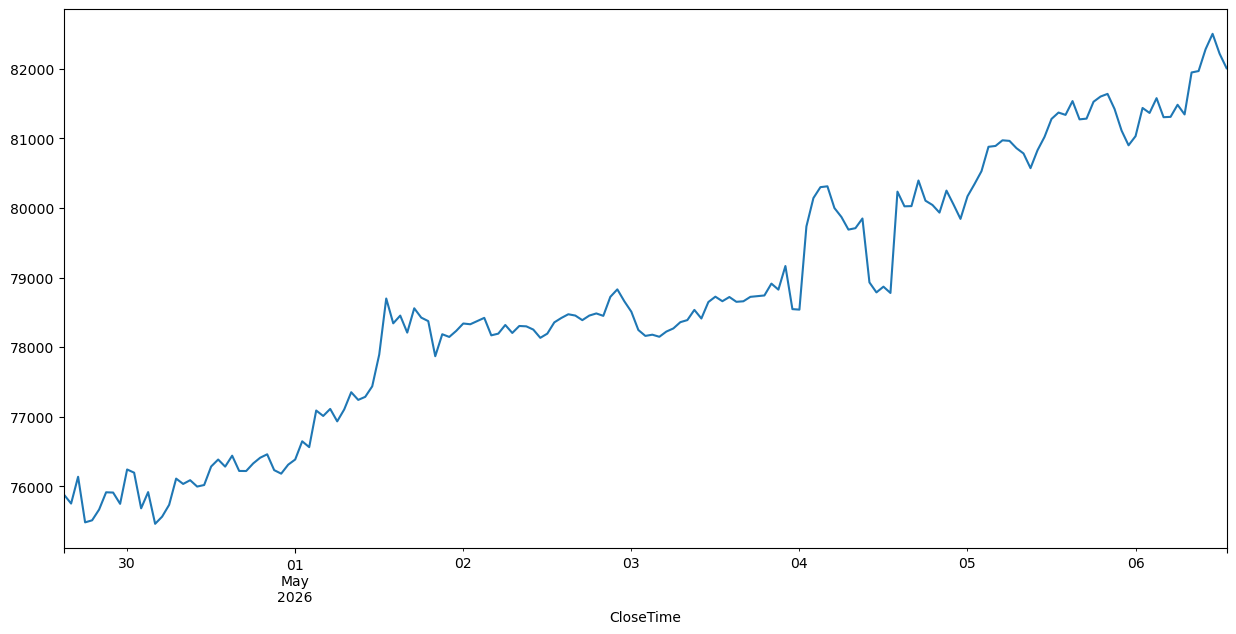

In [18]:
btc['ClosePrice'].plot(figsize=(15, 7))

In [19]:
eth.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-04-29 15:00:00,2298.83,2300.73,2263.06,2271.52,1995.884773
2026-04-29 16:00:00,2271.73,2278.38,2262.24,2265.77,862.188451
2026-04-29 17:00:00,2266.77,2281.12,2265.59,2281.12,326.665824
2026-04-29 18:00:00,2281.83,2288.84,2220.00,2237.80,6192.516988
2026-04-29 19:00:00,2238.84,2241.65,2225.04,2232.12,632.182735


<Axes: xlabel='CloseTime'>

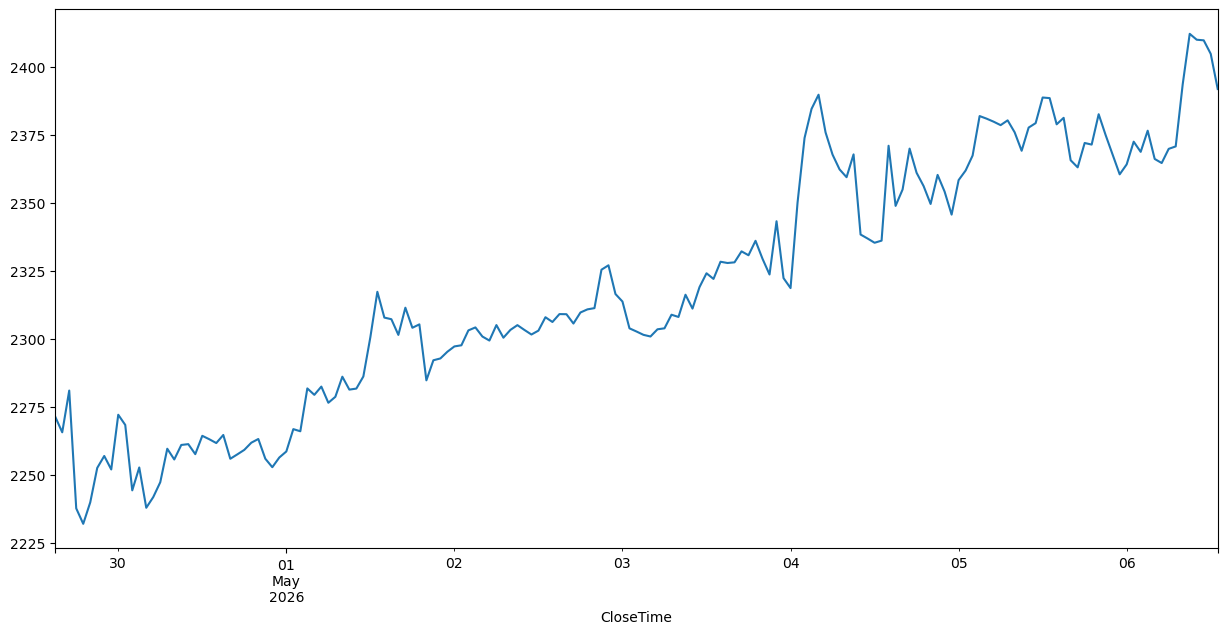

In [20]:
eth['ClosePrice'].plot(figsize=(15, 7))

In [21]:
eth.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-04-29 15:00:00,2298.83,2300.73,2263.06,2271.52,1995.884773
2026-04-29 16:00:00,2271.73,2278.38,2262.24,2265.77,862.188451
2026-04-29 17:00:00,2266.77,2281.12,2265.59,2281.12,326.665824
2026-04-29 18:00:00,2281.83,2288.84,2220.00,2237.80,6192.516988
2026-04-29 19:00:00,2238.84,2241.65,2225.04,2232.12,632.182735
